In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.128', '192.168.10.134']


In [4]:
mgr.scan_local_ports()

2026-05-29 14:51:01,517 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

30.64

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-05-29 14:51:07,391 | INFO     | nlab_modbus.discovery.scan | Register found: 769
2026-05-29 14:51:09,448 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-05-29 14:51:09,479 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [14]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
while next_time - t0 < 15:
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

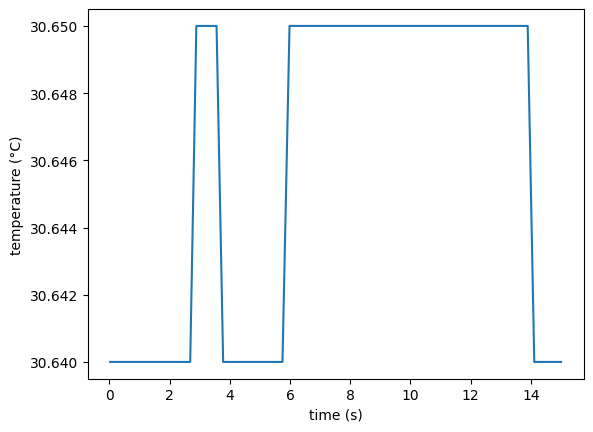

In [15]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

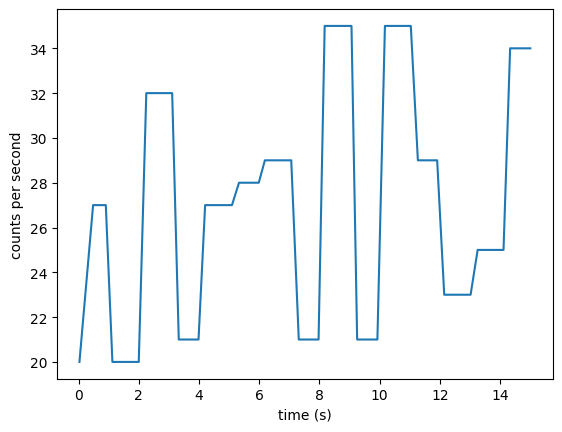

In [16]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [17]:
import numpy as np

In [18]:
np.array(times[1:]) - np.array(times[:-1])

array([0.453, 0.203, 0.219, 0.219, 0.234, 0.203, 0.235, 0.203, 0.25 ,
       0.203, 0.234, 0.204, 0.218, 0.219, 0.234, 0.219, 0.203, 0.219,
       0.234, 0.235, 0.203, 0.219, 0.234, 0.203, 0.219, 0.234, 0.203,
       0.219, 0.235, 0.203, 0.218, 0.25 , 0.204, 0.218, 0.235, 0.203,
       0.219, 0.234, 0.203, 0.234, 0.188, 0.25 , 0.203, 0.219, 0.25 ,
       0.203, 0.234, 0.203, 0.219, 0.235, 0.203, 0.218, 0.219, 0.235,
       0.203, 0.234, 0.219, 0.219, 0.234, 0.203, 0.234, 0.204, 0.218,
       0.219, 0.234, 0.204, 0.234])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0., 21.,  0.,  0.,  0.,  0.,  0.,
         0., 20.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 20.,  0.,  0.,  0.,
         0.,  0.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.188     , 0.19007031, 0.19214062, 0.19421094, 0.19628125,
        0.19835156, 0.20042187, 0.20249219, 0.2045625 , 0.20663281,
        0.20870312, 0.21077344, 0.21284375, 0.21491406, 0.21698437,
        0.21905469, 0.221125  , 0.22319531, 0.22526562, 0.22733594,
      

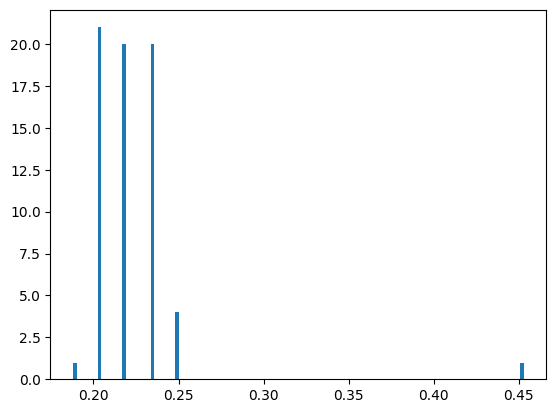

In [19]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=128)

In [20]:
mgr.local[0]

In [21]:
result = mgr.local[0].read_snapshot()

In [22]:
print(result)

{}


In [23]:
from nlab_modbus.core.register_specs import RegisterType
from nlab_modbus.devices.sipm import SiPMDevice

In [24]:
mgr.local[0]._register_index[(RegisterType.HOLDING, 3)]

('vout_set',
 RegisterSpec(reg_type=<RegisterType.HOLDING: 'holding'>, address=3, dtype='uint16', min=1500, max=7800, count=1, scale=0.01, unit='mV'))

In [25]:
count = SiPMDevice.READOUT_STOP - SiPMDevice.READOUT_START

In [26]:
count

19

In [27]:
registers = mgr.local[0].read_raw_block(address=SiPMDevice.READOUT_START, count=count)

In [28]:
registers

[]

In [29]:
test = mgr.local[0].client.read_input_registers(
            address=SiPMDevice.READOUT_START,
            count=count,
            device_id=mgr.local[0].device_id,
        )

In [30]:
test

In [31]:
test.registers

[31, 0, 3002, 8712, 5, 8, 34, 3065, 0, 491, 40, 35536, 0, 0, 0, 31, 0, 5, 0]